# Imports

In [11]:
import os
os.environ["ICTDIR"] = "/Users/user/IC"
import numpy  as np
import pandas as pd
import tables as tb
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import h5py
from invisible_cities.io.channel_param_io import generator_param_reader
from invisible_cities.io.channel_param_io import subset_param_reader as spr
from invisible_cities.io.channel_param_io import basic_param_reader, parameters_and_errors
from functools import partial
import statistics
import itertools
import matplotlib.dates as mdates
from scipy.stats import mode
import matplotlib.cm as cm
import josh_calib_functions as jcf
from invisible_cities.database.load_db  import DataPMT, DataSiPM
from matplotlib.backends.backend_pdf import PdfPages
from copy import deepcopy
from matplotlib import rcParams
import matplotlib as mpl

In [12]:
# Use system fonts instead of LaTeX
mpl.rcParams.update({
    "text.usetex": False,  # <- disable LaTeX
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.figsize": (6, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "lines.linewidth": 2,
    "lines.markersize": 6
})

# Data

In [14]:

common_path = '/Users/user/Calibration_Outputs/'

# pmt_file_paths should be the output files produced from the PMT fitting script, when the fitting range has been set to bins with statistics larger than 100

pmt_file_paths =  [common_path + 'EP_Light_Runs/14731/pmtCalParOut_R14731_min_100.h5',
                  common_path +  'EP_Light_Runs/14750/pmtCalParOut_R14750_min_100.h5',
                  common_path +  'EP_Light_Runs/14788/pmtCalParOut_R14788_min_100.h5',
                  common_path +  'EP_Light_Runs/14821/pmtCalParOut_R14821_min_100.h5',
                  common_path +  'EP_Light_Runs/14844/pmtCalParOut_R14844_min_100.h5',
                  common_path +  'EP_Light_Runs/14871/pmtCalParOut_R14871_min_100.h5',
                  common_path +  'EP_Light_Runs/14884/pmtCalParOut_R14884_min_100.h5',
                  common_path +  'EP_Light_Runs/14990/pmtCalParOut_R14990_min_100.h5',
                  common_path +  'EP_Light_Runs/15067/pmtCalParOut_R15067_min_100.h5',
                  common_path +  'EP_Light_Runs/15182/pmtCalParOut_R15182_min_100.h5',
                  common_path +  'EP_Light_Runs/15213/pmtCalParOut_R15213_min_100.h5',
                  common_path +  'EP_Light_Runs/15259/pmtCalParOut_R15259_min_10.h5', #This run is 10 and not 100 due to being a quick check post power cut.
                  common_path +  'EP_Light_Runs/15277/pmtCalParOut_R15277_min_100.h5',
                  common_path +  'EP_Light_Runs/15294/pmtCalParOut_R15294_min_100.h5',
                  common_path +  'EP_Light_Runs/15329/pmtCalParOut_R15329_min_100.h5',
                  common_path +  'EP_Light_Runs/15483/pmtCalParOut_R15483_min_100.h5',
                  common_path +  'EP_Light_Runs/15512/pmtCalParOut_R15512_min_100.h5',
                  common_path +  'EP_Light_Runs/15551/pmtCalParOut_R15551_min_100.h5',
                  common_path +  'EP_Light_Runs/15584/pmtCalParOut_R15584_min_100.h5',
                  common_path +  'EP_Light_Runs/15631/pmtCalParOut_R15631_min_100.h5',
                  common_path +  'EP_Light_Runs/15654/pmtCalParOut_R15654_min_100.h5', #My first entry
                  common_path +  'EP_Light_Runs/15686/pmtCalParOut_R15686_min_100.h5', #Entry with only 30k events taken during summer school.
                  common_path +  'EP_Light_Runs/15727/pmtCalParOut_R15727_min_500.h5'] #Uses 500 as 100 seed wasn't working. 
                   
# pmt_err_paths should be the output files produced from the PMT fitting script, when the fitting range has been set to bins with statistics larger than 500

pmt_err_paths = [common_path +  'EP_Light_Runs/14731/pmtCalParOut_R14731_min_500.h5',
                  common_path + 'EP_Light_Runs/14750/pmtCalParOut_R14750_min_500.h5',
                  common_path + 'EP_Light_Runs/14788/pmtCalParOut_R14788_min_500.h5',
                  common_path + 'EP_Light_Runs/14821/pmtCalParOut_R14821_min_500.h5',
                  common_path + 'EP_Light_Runs/14844/pmtCalParOut_R14844_min_500.h5',
                  common_path + 'EP_Light_Runs/14871/pmtCalParOut_R14871_min_500.h5',
                  common_path + 'EP_Light_Runs/14884/pmtCalParOut_R14884_min_500.h5',
                  common_path + 'EP_Light_Runs/14990/pmtCalParOut_R14990_min_500.h5',
                  common_path + 'EP_Light_Runs/15067/pmtCalParOut_R15067_min_500.h5',
                  common_path + 'EP_Light_Runs/15182/pmtCalParOut_R15182_min_1000.h5',
                  common_path + 'EP_Light_Runs/15213/pmtCalParOut_R15213_min_500.h5',
                  common_path + 'EP_Light_Runs/15259/pmtCalParOut_R15259_min_50.h5',   #This is 50 and not 500 due to being a quick check post power cut.
                  common_path + 'EP_Light_Runs/15277/pmtCalParOut_R15277_min_500.h5',
                  common_path + 'EP_Light_Runs/15294/pmtCalParOut_R15294_min_500.h5',
                  common_path + 'EP_Light_Runs/15329/pmtCalParOut_R15329_min_500.h5',
                  common_path + 'EP_Light_Runs/15483/pmtCalParOut_R15483_min_500.h5',
                  common_path + 'EP_Light_Runs/15512/pmtCalParOut_R15512_min_500.h5',
                  common_path + 'EP_Light_Runs/15551/pmtCalParOut_R15551_min_500.h5',
                  common_path + 'EP_Light_Runs/15584/pmtCalParOut_R15584_min_500.h5',
                  common_path + 'EP_Light_Runs/15631/pmtCalParOut_R15631_min_500.h5',
                  common_path + 'EP_Light_Runs/15654/pmtCalParOut_R15654_min_500.h5', #My first entry
                  common_path + 'EP_Light_Runs/15686/pmtCalParOut_R15686_min_195.h5', #Entry with only 30k events.
                  common_path + 'EP_Light_Runs/15727/pmtCalParOut_R15727_min_600.h5'] #Uses 600 as the error, as 500 was used for the data in this case.
                 
# sipm_file_paths should be the light spectra output files produced from the SiPM fitting script

sipm_file_paths =  [common_path + 'TP_Light_Runs/14707/sipm_fit_R14707.h5',
                    common_path + 'TP_Light_Runs/14730/sipm_fit_R14730.h5',
                    common_path + 'TP_Light_Runs/14749/sipm_fit_R14749.h5',
                    common_path + 'TP_Light_Runs/14787/sipm_fit_R14787.h5',
                    common_path + 'TP_Light_Runs/14820/sipm_fit_R14820.h5',
                    common_path + 'TP_Light_Runs/14843/sipm_fit_R14843.h5',
                    common_path + 'TP_Light_Runs/14870/sipm_fit_R14870.h5',
                    common_path + 'TP_Light_Runs/14883/sipm_fit_R14883.h5',
                    common_path + 'TP_Light_Runs/14989/sipm_fit_R14989.h5',
                    common_path + 'TP_Light_Runs/15066/sipm_fit_R15066.h5',
                    common_path + 'TP_Light_Runs/15192/sipm_fit_R15192.h5',
                    common_path + 'TP_Light_Runs/15212/sipm_fit_R15212.h5',
                    common_path + 'TP_Light_Runs/15262/sipm_fit_R15262.h5',
                    common_path + 'TP_Light_Runs/15275/sipm_fit_R15275.h5',
                    common_path + 'TP_Light_Runs/15293/sipm_fit_R15293.h5',
                    common_path + 'TP_Light_Runs/15328/sipm_fit_R15328.h5',
                    common_path + 'TP_Light_Runs/15482/sipm_fit_R15482.h5',
                    common_path + 'TP_Light_Runs/15511/sipm_fit_R15511.h5',
                    common_path + 'TP_Light_Runs/15550/sipm_fit_R15550.h5',
                    common_path + 'TP_Light_Runs/15583/sipm_fit_R15583.h5',
                    common_path + 'TP_Light_Runs/15612/sipm_fit_R15612.h5',
                    common_path + 'TP_Light_Runs/15630/sipm_fit_R15630.h5',
                    common_path + 'TP_Light_Runs/15653/sipm_fit_R15653.h5', #My first entry
                    common_path + 'TP_Light_Runs/15685/sipm_fit_R15685.h5',
                    common_path + 'TP_Light_Runs/15728/sipm_fit_R15728.h5']

# sipm_dark_file_paths should be the dark spectra output files produced from the SiPM fitting script. The same run as the light run, just the dark part of it, not the actual dark runs.

sipm_dark_file_paths = [common_path + 'TP_Light_Runs/14707/dark_sipm_fit_R14707.h5',
                        common_path + 'TP_Light_Runs/14730/dark_sipm_fit_R14730.h5',
                        common_path + 'TP_Light_Runs/14749/dark_sipm_fit_R14749.h5',
                        common_path + 'TP_Light_Runs/14787/dark_sipm_fit_R14787.h5',
                        common_path + 'TP_Light_Runs/14820/dark_sipm_fit_R14820.h5',
                        common_path + 'TP_Light_Runs/14843/dark_sipm_fit_R14843.h5',
                        common_path + 'TP_Light_Runs/14870/dark_sipm_fit_R14870.h5',
                        common_path + 'TP_Light_Runs/14883/dark_sipm_fit_R14883.h5',
                        common_path + 'TP_Light_Runs/14989/dark_sipm_fit_R14989.h5',
                        common_path + 'TP_Light_Runs/15066/dark_sipm_fit_R15066.h5',
                        common_path + 'TP_Light_Runs/15192/sipm_fit_R15192.h5',
                        common_path + 'TP_Light_Runs/15212/dark_sipm_fit_R15212.h5',
                        common_path + 'TP_Light_Runs/15262/dark_sipm_fit_R15262.h5',
                        common_path + 'TP_Light_Runs/15275/dark_sipm_fit_R15275.h5',
                        common_path + 'TP_Light_Runs/15293/dark_sipm_fit_R15293.h5',
                        common_path + 'TP_Light_Runs/15328/dark_sipm_fit_R15328.h5',
                        common_path + 'TP_Light_Runs/15482/dark_sipm_fit_R15482.h5',
                        common_path + 'TP_Light_Runs/15511/dark_sipm_fit_R15511.h5',
                        common_path + 'TP_Light_Runs/15550/dark_sipm_fit_R15550.h5',
                        common_path + 'TP_Light_Runs/15583/dark_sipm_fit_R15583.h5',
                        common_path + 'TP_Light_Runs/15612/dark_sipm_fit_R15612.h5',
                        common_path + 'TP_Light_Runs/15630/dark_sipm_fit_R15630.h5',
                        common_path + 'TP_Light_Runs/15653/dark_sipm_fit_R15653.h5', #My first entry
                        common_path + 'TP_Light_Runs/15685/dark_sipm_fit_R15685.h5',
                        common_path + 'TP_Light_Runs/15728/dark_sipm_fit_R15728.h5']

# These are the dates that correspond to the input files

pmt_dates = ['20/01/2025',
             '27/01/2025',
             '03/02/2025',
             '10/02/2025',
             '17/02/2025',
             '24/02/2025',
             '03/03/2025',
             '17/03/2025',
             '24/03/2025',
             '07/04/2025',
             '14/04/2025',
             '29/04/2025',
             '06/05/2025',
             '12/05/2025',
             '19/05/2025',
             '27/05/2025',
             '09/06/2025',
             '25/06/2025',
             '07/07/2025',
             '04/08/2025',
             '18/08/2025', #My first entry
             '08/09/2025',
             '22/09/2025']

sipm_dates = ['16/01/2025',
              '20/01/2025',
              '27/01/2025',
              '03/02/2025',
              '10/02/2025',
              '17/02/2025',
              '24/02/2025',
              '03/03/2025',
              '17/03/2025',
              '24/03/2025',
              '08/04/2025',
              '14/04/2025',
              '29/04/2025',
              '06/05/2025',
              '12/05/2025',
              '19/05/2025',
              '27/05/2025',
              '09/06/2025',
              '25/06/2025',
              '07/07/2025',
              '22/07/2025',
              '04/08/2025',
              '18/08/2025', #My first entry
              '08/09/2025',
              '22/09/2025']
              
              
pmt_dates = [dt.datetime.strptime(d,'%d/%m/%Y').date() for d in pmt_dates]

sipm_dates = [dt.datetime.strptime(d,'%d/%m/%Y').date() for d in sipm_dates]

In [15]:
# Define masked Sensor IDs
masked_pmt_IDs = [3, 24, 26, 36, 37, 38, 39, 40, 41, 48, 50, 53, 58]
masked_sipm_IDs = [1010, 1011, 6055, 9004, 38057, 45058]

# Extract relevant values from the input files

pmt_stability = []
pmt_gains = []
pmt_gain_err = []
pmt_pedestal_sigma = []
pmt_pedestal_sigma_err = []
pmt_poisson_mu = []
pmt_poisson_mu_err = []
pmt_gain_sigma = []
pmt_gain_sigma_err = []
pmt_ID = []

pmt_err_gain = []
pmt_err_gain_err = []

sipm_stability = []
sipm_gains = []
sipm_gain_err = []
sipm_ID = []

sipm_dcr = []
sipm_dcr_err = []
sipm_dark_gain = []
sipm_dark_gain_err = []

for path in pmt_file_paths:
    values = jcf.obtain_stability_params(path)
    mask = ~values.SensorID.isin(masked_pmt_IDs)
    
    pmt_stability.append(values[mask])
    pmt_gains.append(values.gain[mask].tolist())
    pmt_gain_err.append(values.u_gain[mask])
    pmt_pedestal_sigma.append(values.pedestal_sigma[mask])
    pmt_pedestal_sigma_err.append(values.u_pedestal_sigma[mask])
    pmt_poisson_mu.append(values.poisson_mu[mask])
    pmt_poisson_mu_err.append(values.u_poisson_mu[mask])
    pmt_gain_sigma.append(values.gain_sigma[mask])
    pmt_gain_sigma_err.append(values.u_gain_sigma[mask])
    pmt_ID.append(values.SensorID[mask])

for path in pmt_err_paths:
    values = jcf.obtain_stability_params(path)
    mask = ~values.SensorID.isin(masked_pmt_IDs)
    
    pmt_err_gain.append(values.gain[mask].tolist())
    pmt_err_gain_err.append(values.u_gain[mask])

for path in sipm_file_paths:
    values = jcf.obtain_stability_params(path)
    mask = ~values.SensorID.isin(masked_sipm_IDs)
    
    sipm_stability.append(values[mask])
    sipm_gains.append(values.gain[mask])
    sipm_gain_err.append(values.u_gain[mask])
    sipm_ID.append(values.SensorID[mask])

for path in sipm_dark_file_paths:
    values = jcf.obtain_stability_params(path)
    mask = ~values.SensorID.isin(masked_sipm_IDs)
    
    sipm_dcr.append(values.poisson_mu[mask])
    sipm_dcr_err.append(values.u_poisson_mu[mask])
    sipm_dark_gain.append(values.gain[mask])
    sipm_dark_gain_err.append(values.u_gain[mask])

# SiPMs

In [16]:
# Calculate the error on the SiPM gain

sipm_gains = np.array(sipm_gains)
sipm_dark_gain = np.array(sipm_dark_gain)
sipm_gain_err = np.array(sipm_gain_err)
sipm_dark_gain_err = np.array(sipm_dark_gain_err)

diff = (sipm_gains) - (sipm_dark_gain)
total_err = np.sqrt(diff**2+ sipm_gain_err**2 + sipm_dark_gain_err**2)

In [17]:
# Obtain DICE averages

db_gains = []
db_gains_err = []

db_dark_gains = []
db_dark_gains_err = []

for i in range(len(sipm_file_paths)):
    dice_avg, dice_avg_err = jcf.avg_gain_by_db(sipm_gains[i], total_err[i])
    db_gains.append(dice_avg)
    db_gains_err.append(dice_avg_err)

for i in range(len(sipm_dark_file_paths)):
    dice_avg, dice_avg_err = jcf.avg_gain_by_db(sipm_dark_gain[i], sipm_dark_gain_err[i])
    db_dark_gains.append(dice_avg)
    db_dark_gains_err.append(dice_avg_err)
    
db_gains = np.array(db_gains)
db_gains_err = np.array(db_gains_err)

db_dark_gains = np.array(db_dark_gains)
db_dark_gains_err = np.array(db_dark_gains_err)

dice_number = np.linspace(0,55,56)

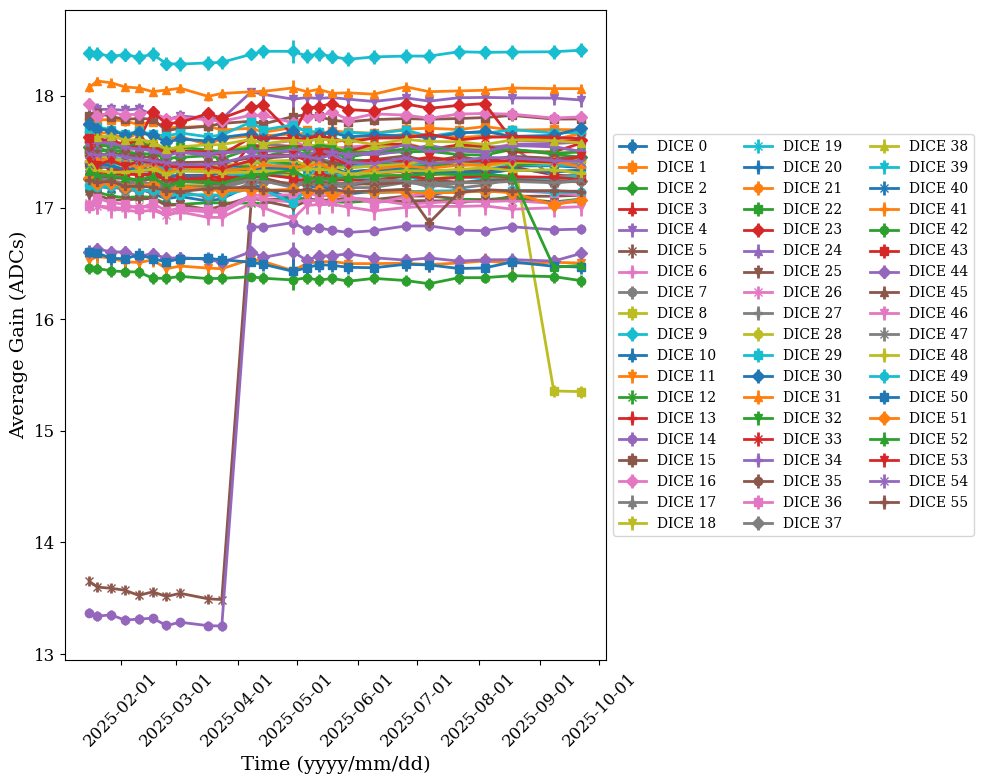

In [18]:
# Plot DICE averages

reshaped_gains = np.array(db_dark_gains).T
reshaped_errors = np.array(db_dark_gains_err).T
sipm_dates = pd.to_datetime(sipm_dates)
dice_number = np.array(dice_number, dtype=int)

markers = itertools.cycle(['o', 's', 'D', '^', 'v', 'x', 'P'])
colors = itertools.cycle(plt.cm.tab10.colors)

plt.figure(figsize=(10, 8))

for i in range(len(reshaped_gains)):
    plt.errorbar(sipm_dates, reshaped_gains[i], yerr = reshaped_errors[i], 
             marker=next(markers), color=next(colors), 
             linestyle='-', label=f'DICE {dice_number[i]}')

plt.xlabel("Time (yyyy/mm/dd)")
plt.ylabel("Average Gain (ADCs)")
#plt.title("DICE Gains (dark spectra) Over Time")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())

plt.legend(ncol=3, fontsize='small', loc='center left', bbox_to_anchor=(1, 0.5))

plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
#plt.ylim(0,40)
plt.show()

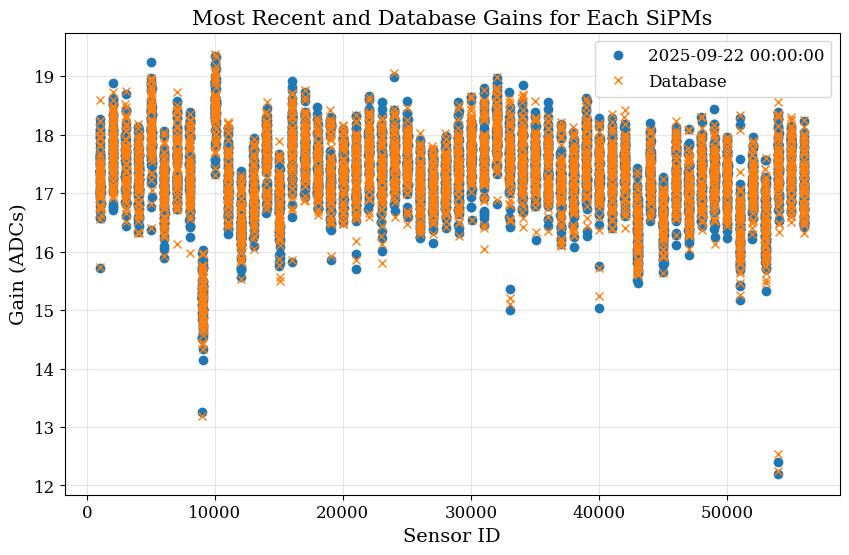

In [19]:
ID_now = sipm_ID[-1]
gain_now = sipm_dark_gain[-1]
date_now = sipm_dates[-1]

ID_database = DataSiPM('next100', 15728).SensorID.values
gain_database = DataSiPM('next100', 15728).adc_to_pes.values

ID_database = np.array(ID_database)
gain_database = np.array(gain_database)

mask = np.isin(ID_database, masked_sipm_IDs, invert=True)
ID_database_masked = ID_database[mask]
gain_database_masked = gain_database[mask]

plt.figure(figsize=(10, 6))
plt.plot(ID_now, gain_now, 'o', label=f'{date_now}')
plt.plot(ID_database_masked, gain_database_masked, 'x', label='Database')

plt.xlabel('Sensor ID')
plt.ylabel('Gain (ADCs)')
plt.title('Most Recent and Database Gains for Each SiPMs')
plt.legend()
plt.grid(True)
plt.show()


In [20]:
threshold_upper = 20
threshold_lower = 14

ID_now = np.array(ID_now)
indices_lower = np.where(gain_now<threshold_lower)
sensors_lower = ID_now[indices_lower]
indices_upper = np.where(gain_now>threshold_upper)
sensors_upper = ID_now[indices_upper]

print("Check the spectra of sensors", sensors_lower, "and", sensors_upper)

Check the spectra of sensors [ 9011 54000 54001] and []


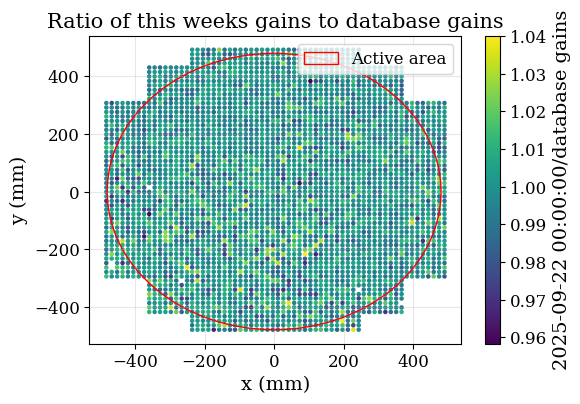

Check the spectra of sensors [] and []


In [21]:
pos_x  = DataSiPM('next100', 15728).X.values
pos_y  = DataSiPM('next100', 15728).Y.values

pos_x_masked = pos_x[mask]
pos_y_masked = pos_y[mask]

ratio = gain_now/gain_database_masked

circle = plt.Circle((0,0),480, color = 'r', fill = False, label = 'Active area')

fig, ax = plt.subplots()

ax.add_patch(circle)

plt.scatter(pos_x_masked, pos_y_masked, s=5, c=ratio)
plt.colorbar(label = f'{sipm_dates[-1]}/database gains')
plt.title(f"Ratio of this weeks gains to database gains")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.legend()
plt.show()

threshold_lower = 0.9
threshold_upper = 1.1

indices_lower = np.where(ratio<threshold_lower)
sensors_lower = ID_now[indices_lower]
indices_upper = np.where(ratio>threshold_upper)
sensors_upper = ID_now[indices_upper]


print("Check the spectra of sensors", sensors_lower, "and", sensors_upper)

In [22]:
print((ratio[1485]))

1.0186682811082124


# PMTs

In [23]:
pmt_gains = np.array(pmt_gains)
pmt_err_gain = np.array(pmt_err_gain)
pmt_gain_err = np.array(pmt_gain_err)
pmt_err_gain_err = np.array(pmt_err_gain_err)

diff = pmt_gains - pmt_err_gain
new = np.array([pmt_gains, pmt_err_gain])
avg = (pmt_gains + pmt_err_gain)/2
diff_err = sum(new-avg)**2

pmt_total_err = np.sqrt(diff**2 + diff_err**2 + pmt_gain_err**2 + pmt_err_gain_err**2)

In [24]:
print(pmt_gains[-1][45])

0.0


In [25]:
print(reshaped_gains[-1])

[17.245443 17.22684  17.235292 17.191067 17.191494 17.181694 17.15012
 17.14347  17.16856  17.17793  17.181501 17.157835 17.146193 17.16284
 17.143679 17.164108 17.139774 17.151127 17.163273 16.86519  17.134087
 17.16188  17.148357 17.151928 17.140789]


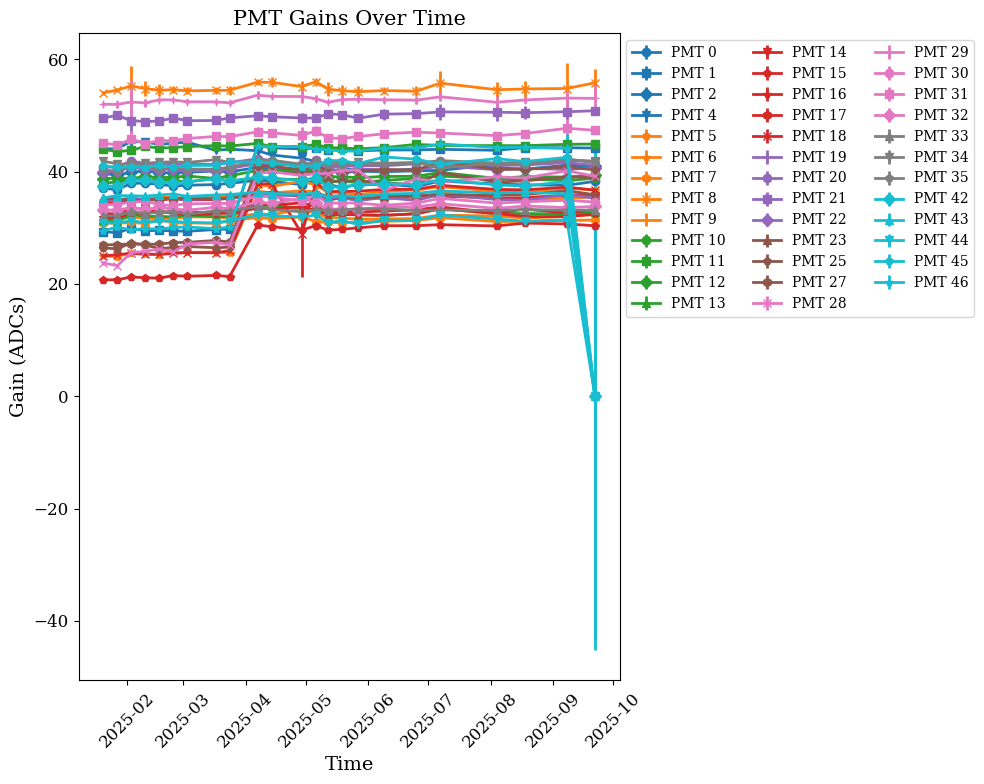

In [26]:
#faulty_pmt_indices = [3, 24, 26, 36, 37, 38, 39, 40, 41, 48, 50, 53, 58]
faulty_pmt_indices = [3, 24, 26, 36, 37, 38, 39, 40, 41, 48, 50, 53, 58]

reshaped_gains = np.array(pmt_gains).T
reshaped_errors = np.array(pmt_total_err).T
pmt_dates_time = pd.to_datetime(pmt_dates)

#I added this for-loop here as the original plots gave the index of the list and not the actual PMT numbers for the plot.
#actual_pmt_numbers=[]
#for i in pmt_ID[0]:
    #if num not in faulty_pmt_indices:
        #actual_pmt_numbers.append(pmt_ID[0][i])

markers = ['o', 's', 'D', '^', 'v', 'p', '*', 'h', 'x', '+'] 
colors = plt.cm.tab10(np.linspace(0, 1, len(reshaped_gains)))

plt.figure(figsize=(10, 8))
for i, (gain, error, color) in enumerate(zip(reshaped_gains, reshaped_errors, colors)):
    if i not in faulty_pmt_indices:
        marker = markers[i % len(markers)]  # Cycle through markers
        plt.errorbar(pmt_dates_time, gain, yerr=error, marker=marker, color=color, linestyle='-', label=f'PMT {pmt_ID[0][i]}')

plt.xlabel("Time")
plt.ylabel("Gain (ADCs)")
plt.title("PMT Gains Over Time")
plt.legend(ncol=3, fontsize='small', loc='upper left', bbox_to_anchor=(1, 1))
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

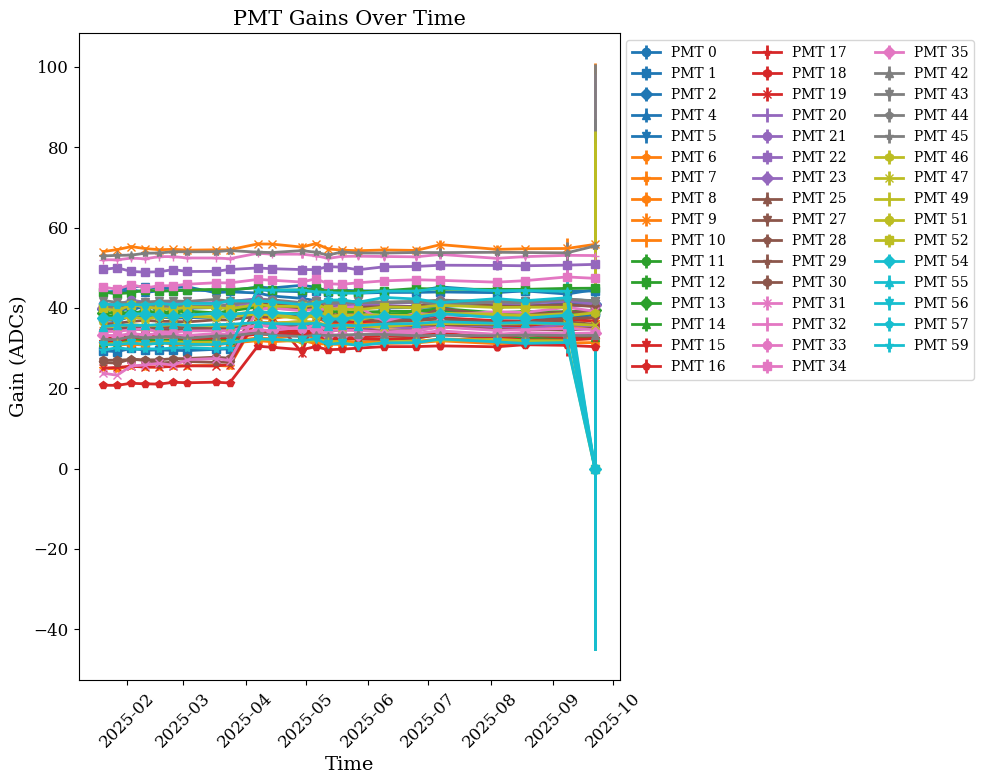

In [27]:
#My adapted plotting code, as some PMTs were missing on the other plot

faulty_pmt_indices = [3, 24, 26, 36, 37, 38, 39, 40, 41, 48, 50, 53, 58]

reshaped_gains = np.array(pmt_gains).T
reshaped_errors = np.array(pmt_total_err).T
pmt_dates_time = pd.to_datetime(pmt_dates)

#I added this for-loop here as the original plots gave the index of the list and not the actual PMT numbers for the plot.
actual_pmt_numbers=[]
for i in pmt_ID[0]:
    if i not in faulty_pmt_indices:
        actual_pmt_numbers.append(pmt_ID[0][i])

markers = ['o', 's', 'D', '^', 'v', 'p', '*', 'h', 'x', '+', 'o', 's', 'D', '^', 'v', 'p', '*', 'h', 'x', '+', 'o', 's', 'D', '^', 'v', 'p', '*', 'h', 'x', '+', 'o', 's', 'D', '^', 'v', 'p', '*', 'h', 'x', '+', 'o', 's', 'D', '^', 'v', 'p', '*', 'h', 'x', '+', 'o', 's', 'D', '^', 'v', 'p', '*', 'h', 'x', '+', 'o', 's', 'D', '^', 'v', 'p', '*', 'h', 'x', '+'] 
colors = plt.cm.tab10(np.linspace(0, 1, len(pmt_gains[0])))

plt.figure(figsize=(10,8))
for i in range(len(pmt_gains[-1])):
    values_for_pmt_across_time=[]
    col=colors[i]
    mak=markers[i]
    for j in range(len(pmt_gains)):
        values_for_pmt_across_time.append(pmt_gains[j][i])
    plt.errorbar(pmt_dates_time, values_for_pmt_across_time, yerr=error, color=col, marker=mak, linestyle='-', label=f'PMT {actual_pmt_numbers[i]}')

plt.xlabel("Time")
plt.ylabel("Gain (ADCs)")
plt.title("PMT Gains Over Time")
plt.legend(ncol=3, fontsize='small', loc='upper left', bbox_to_anchor=(1, 1))
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

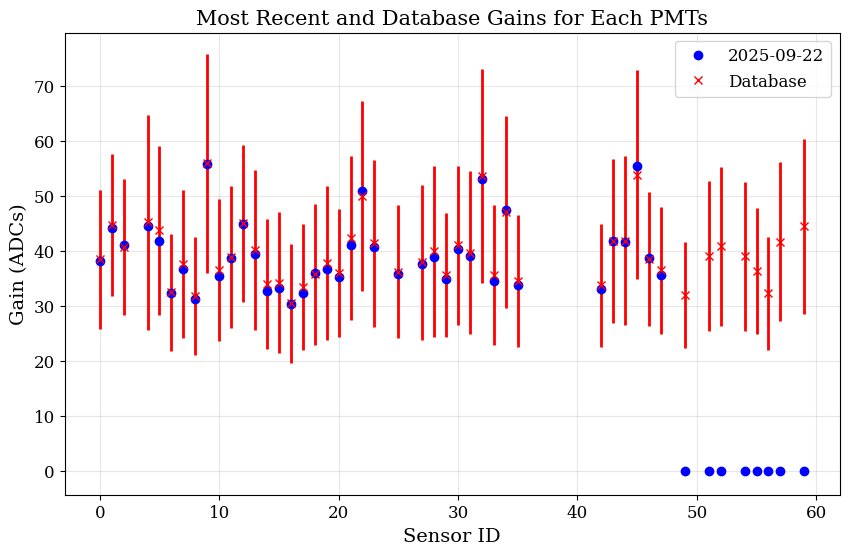

In [28]:
ID_now = pmt_ID[-1]
gain_now = pmt_gains[-1]
date_now = pmt_dates[-1]
error_now= pmt_err_gain_err[-1]

ID_database = DataPMT('next100', 15727).SensorID.values
gain_database = DataPMT('next100', 15727).adc_to_pes.values
error_database = DataPMT('next100', 15727).Sigma

ID_database = np.array(ID_database)
gain_database = np.array(gain_database)
error_database = np.array(error_database)

mask = np.isin(ID_database, masked_pmt_IDs, invert=True)
ID_database_masked = ID_database[mask]
gain_database_masked = gain_database[mask]
error_database_masked = error_database[mask]

plt.figure(figsize=(10, 6))
plt.plot(ID_now, gain_now, 'o', label=f'{date_now}', color='blue')
plt.errorbar(ID_now, gain_now, yerr=error_now, color='blue', ls='none')
plt.plot(ID_database_masked, gain_database_masked, 'x', label='Database', color='red')
plt.errorbar(ID_database_masked, gain_database_masked, yerr=error_database_masked, color='red', ls='none')


plt.xlabel('Sensor ID')
plt.ylabel('Gain (ADCs)')
plt.title('Most Recent and Database Gains for Each PMTs')
plt.legend()
plt.grid(True)
plt.show()

In [29]:
threshold_upper = 60
threshold_lower = 20

ID_now = np.array(ID_now)
indices_lower = np.where(gain_now<threshold_lower)
sensors_lower = ID_now[indices_lower]
indices_upper = np.where(gain_now>threshold_upper)
sensors_upper = ID_now[indices_upper]

print("Check the spectra of sensors", sensors_lower, "and", sensors_upper)

Check the spectra of sensors [49 51 52 54 55 56 57 59] and []


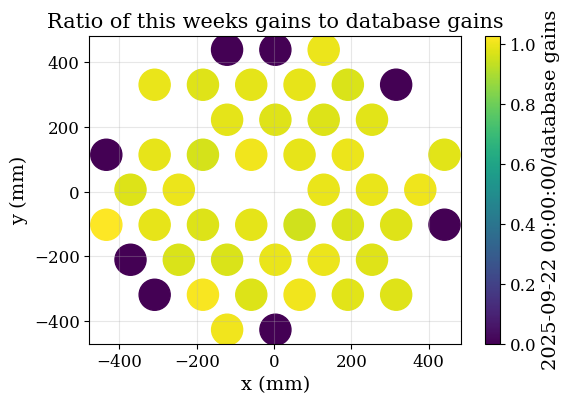

Check the spectra of sensors [49 51 52 54 55 56 57 59] and []


In [30]:
pos_x  = DataPMT('next100', 15727).X.values
pos_y  = DataPMT('next100', 15727).Y.values

pos_x_masked = pos_x[mask]
pos_y_masked = pos_y[mask]

ratio = gain_now/gain_database_masked

fig, ax = plt.subplots()

plt.scatter(pos_x_masked, pos_y_masked, s=500, c=ratio)
plt.colorbar(label = f'{sipm_dates[-1]}/database gains')
plt.title(f"Ratio of this weeks gains to database gains")
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.show()

threshold_lower = 0.95
threshold_upper = 1.05

indices_lower = np.where(ratio<threshold_lower)
sensors_lower = ID_now[indices_lower]
indices_upper = np.where(ratio>threshold_upper)
sensors_upper = ID_now[indices_upper]


print("Check the spectra of sensors", sensors_lower, "and", sensors_upper)

In [31]:
print(ratio)

[0.99435272 0.98958858 1.00589228 0.98599321 0.95591207 0.99498905
 0.97562636 0.98552246 0.99796909 0.97029202 0.9989776  0.9974864
 0.97955878 0.96326005 0.97266337 0.99626251 0.96905921 1.00355116
 0.9721751  0.97945523 0.97249765 1.01792663 0.98181246 0.98989881
 0.99112665 0.97583494 0.979562   0.98211107 0.98742139 0.98940531
 0.97002941 1.00590036 0.97786906 0.98096063 0.99999953 0.99417531
 1.0285853  1.00848837 0.97770995 0.         0.         0.
 0.         0.         0.         0.         0.        ]


In [32]:
print(np.argmax(ratio))

36


In [33]:
print(actual_pmt_numbers[36])

45


In [34]:
print(len(actual_pmt_numbers))

47


In [35]:
print(actual_pmt_numbers)

[0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 27, 28, 29, 30, 31, 32, 33, 34, 35, 42, 43, 44, 45, 46, 47, 49, 51, 52, 54, 55, 56, 57, 59]
